---
title: Lennard Jones Assignment
authors: gvarnavides
date: 2026-05-01
---

So far in the course we have focused on non-interacting systems.
In contrast, real systems consist of many particles that interact with one another.
As a first step in this direction, we will investigate the classical thermodynamics and statistical physics of a diatomic molecule, or dimer, whose atoms interact via the Lennard Jones potential, and analyze its continuum of microstates.

### Lennard Jones Potential

The Lennard Jones potential is a model for a particle's potential energy when it is separated from another particle. 
The model is simple -- particles attract each other when they are far apart and repel when they are very near.
All of the physics and its consequences derive from the shape of the potential:
- When the distance is small, the potential energy decreases with increasing distance.
  The force is positive and repulsive because force is minus the gradient of potential energy.
- When the distance is large, the potential energy slope is positive and so the force is negative: the particles attract.

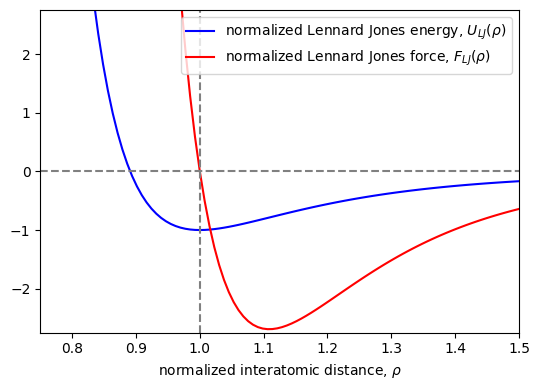

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def normalized_lj_potential(rho):
    rho_inverse_6 = rho**(-6)
    potential = rho_inverse_6**2 - 2* rho_inverse_6
    return potential

def normalized_lj_force(rho):
    rho_inverse_6 = rho**(-6)
    force = 12.0 * (rho_inverse_6**2 - rho_inverse_6) / rho
    return force

rho = np.linspace(0.75,1.5,100)
lj_energy = normalized_lj_potential(rho)
lj_force = normalized_lj_force(rho)

fig, ax = plt.subplots(figsize=(5.5,4))
ax.plot(rho,lj_energy,color='blue',label=r'normalized Lennard Jones energy, $U_{LJ}(\rho)$')
ax.plot(rho,lj_force,color='red',label=r'normalized Lennard Jones force, $F_{LJ}(\rho)$')
ax.hlines([0],0.75,1.5,linestyles='dashed',color='gray')
ax.vlines(1.0,-2.75,2.75,linestyles='dashed',color='gray')
ax.set(
    xlim=[0.75,1.5],
    ylim=[-2.75,2.75],
    xlabel=r"normalized interatomic distance, $\rho$",
)
ax.legend()
fig.tight_layout()

We work with a non-dimensional form of the Lennard–Jones potential, where distances are scaled by the equilibrium separation, $\rho = r/r_{\min}$, and energies by the well depth, $\tilde{U} = U / |U_{\min}|$.
In these units, the potential has its minimum at $\rho = 1$ with energy $-1$, allowing us to focus on the general behavior rather than material-specific parameters.

The Lennard–Jones potential is commonly written as a combination of a short-range repulsive and long-range attractive term:
- A repulsive term that diverges as $r \to 0$
- An attractive term that decays as $r \to \infty$

$$
U(r) = \frac{a}{r^{12}} + \frac{b}{r^6},
$$

where $a$ and $b$ are material-dependent parameters.

To study the general behavior of this class of potentials, we introduce dimensionless variables:
- $\rho = r / r_{\min}$ (distance scaled by the equilibrium separation)
- $\tilde{U} = U / |U_{\min}|$ (energy scaled by the well depth)

In these units, the potential takes the universal form
$$
\tilde{U}(\rho) = \frac{1}{\rho^{12}} - \frac{2}{\rho^6},
$$
which has its minimum at $\rho = 1$ with $\tilde{U} = -1$.

### Velocity Verlet Integration

We are interested in capturing the dynamics of a Lennard-Jones dimer evolving at constant energy, i.e. forming a micro-canonical ensemble.
To do so, we need to integrate the classical equations of motion (EOM) using a symplectic (energy-conserving) integrator.


A simple and widely used symplectic integrator, is given by the leap-frog or [Velocity Verlet](wiki:Verlet_integration#Velocity_Verlet) method, which updates position and momentum in a staggered way, which helps maintain good energy conservation over long times:

The algorithm advances the system from time step $n$ to $n+1$ via:
$$
\begin{aligned}
        p_{n+1/2} &= p_n       + \frac{dt}{2} \, F(q_n) \\
        q_{n+1}   &= q_n       + dt  \,   p_{n+1/2} \\
        p_{n+1}   &= p_{n+1/2} + \frac{dt}{2} \, F(q_{n+1})
\end{aligned}
$$

where $q_n$ and $p_n$ are the position and momentum at time step $n$, and $F(q) = -\partial U / \partial q$ is the force.

You can use the provided [source-code](./lj-dimer-source-code) to integrate the EOM of a displaced dimer, where the particles are interacting with an arbirtary force function:

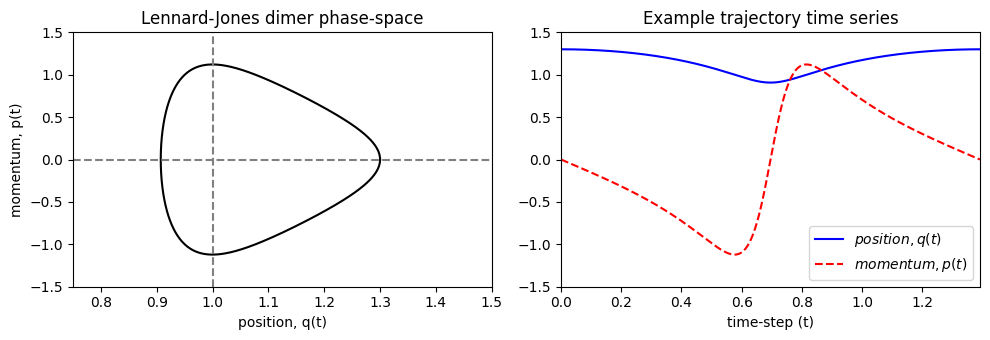

In [ ]:
#| label: lj_example_trajectory
from lj_dimer import velocity_verlet_integrator

trajectory_positions,trajectory_momenta, trajectory_time = velocity_verlet_integrator(
    initial_position=1.3,
    force_function=normalized_lj_force,
)

fig,axs = plt.subplots(1,2,figsize=(10,3.5))
axs[0].plot(trajectory_positions,trajectory_momenta,color='k')
axs[0].set(
    xlabel='position, q(t)',
    ylabel='momentum, p(t)',
    xlim=[0.75,1.5],
    ylim=[-1.5,1.5],
    title="Lennard-Jones dimer phase-space"
)
axs[0].hlines(0,0.75,1.5,linestyles='dashed',color='gray')
axs[0].vlines(1,-1.5,1.5,linestyles='dashed',color='gray')
axs[1].plot(trajectory_time,trajectory_positions,color='blue',label=r'$position, q(t)$')
axs[1].plot(trajectory_time,trajectory_momenta,color='red',linestyle='dashed',label=r'$momentum, p(t)$')
axs[1].legend()
axs[1].set(
    xlabel='time-step (t)',
    xlim=[0,trajectory_time[-1]],
    ylim=[-1.5,1.5],
    title="Example trajectory time series"
)
fig.tight_layout()

### Part 1a: Energy Conservation

Using the provided code, evolve the displaced Lennard–Jones dimer in time to obtain a periodic orbit.

- Compute and plot the total energy as a function of time, and verify that it is conserved.
- Repeat the simulation for different time-steps $dt$, and quantify how the energy conservation (e.g., drift or fluctuations) depends on $dt$.

### Part 1b: Periodic Orbits

Using the provided code, compute periodic orbits of the Lennard–Jones dimer and visualize them in phase space $(q(t), p(t))$.

Construct $N = 100$ bound orbits by choosing different initial displacements $q_0$ (with initial momentum set to zero), and for each case evolve the system over one period.

Do this in two ways:
- Choose $q_0$ values that are evenly spaced in position (distance).
- Choose $q_0$ values such that the corresponding total energies are evenly spaced (you will need to determine the appropriate $q_0$ values to achieve this).

For each case:
- Compute the trajectories $(q(t), p(t))$.
- Plot all orbits together in a single phase-space portrait, coloring each orbit by its total energy.

### Part 1c: Microcanonical Ensemble

Each periodic orbit corresponds to a continuous set of microstates at a fixed total energy.
The number of accessible microstates (i.e. the _multiplicity_) can be obtained, starting from the area enclosed by the orbit in phase space.

More precisely, define
$$
J(E) = \frac{1}{2\pi} \oint p \, dq
$$
which is proportional to the area enclosed by the closed orbit in $(q,p)$ space.

The multiplicity is then given by
$$
\Omega(E) = \frac{dJ}{dE}.
$$

- Using the orbits constructed above with initial conditions equispaced in energy, compute and plot $J(E)$ numerically by estimating the area enclosed by each orbit in phase space.
  - _Hint:_ treat each orbit as a closed polygon in $(q,p)$ and use the Shoelace_formula to compute its area.
- Compute and plot the multiplicity $\Omega(E)$ by numerically differentiating $J(E)$ with respect to $E$.
  - _Hint:_ you may find `scipy.interpolate.CubicSpline` useful for obtaining a smooth derivative.
- Compute and plot the microcanonical entropy $S(E) = \log \Omega(E)$.
- Validate that the orbit period satisfies $T(E) = 2\pi \frac{dJ}{dE},$ by comparing the measured period of each orbit to the derivative of $J(E)$.

### Part 1d: Canonical Ensemble

In the canonical ensemble, the partition function is given by
$$
Z(\beta) = \int \Omega(E)\, e^{-\beta E} \, dE,
$$
where $\beta = 1/(k_B T)$ and $\Omega(E)$ is the multiplicity computed previously.

All thermodynamic quantities can be derived from $Z(\beta)$.
- Compute $Z(\beta)$ numerically using your results for $\Omega(E)$.  
- Use it to compute the internal energy $U = \langle E \rangle$ and the heat capacity $C$.
  - Plot $U$ and $C$ as a function of $k_B T$.

### Part 1e: Unbound States

The heat capacity approaching zero at high temperatures is a consequence of restricting to bound states ($E < 0$).
For $E > 0$, the Lennard–Jones potential describes unbound states, where the dimer dissociates and the two particles behave as free particles ($q \to \infty$).

To include these states, we model the relative motion as a free particle in a 1D box of length $L$, with partition function
$$
Z_{\mathrm{free}}(\beta) = \frac{L}{\sqrt{2\pi \beta}}.
$$

_Recall:_ we work in natural units, so constants such as Planck’s constant from your lecture notes do not appear above.

The total partition function is then the sum of the bound and free contributions:
$$
Z_{\mathrm{total}}(\beta) = Z_{\mathrm{bound}}(\beta) + Z_{\mathrm{free}}(\beta).
$$

- Repeat the calculations of the internal energy $U$ and heat capacity $C$, now using $Z_{\mathrm{total}}(\beta)$ with $L = 10$.
- Plot the heat capacity for several values of $L$, and comment on how the result depends on the box size.
- Explain the physical meaning of the high-temperature limit in this extended model.

### Part 1f: Harmonic Approximation

At low energies, the dimer oscillates near the minimum of the potential and can be well approximated by a harmonic oscillator:
$$
U_{\mathrm{HO}}(\rho) = -1 + 36(\rho - 1)^2 + O\!\left((\rho - 1)^3\right).
$$

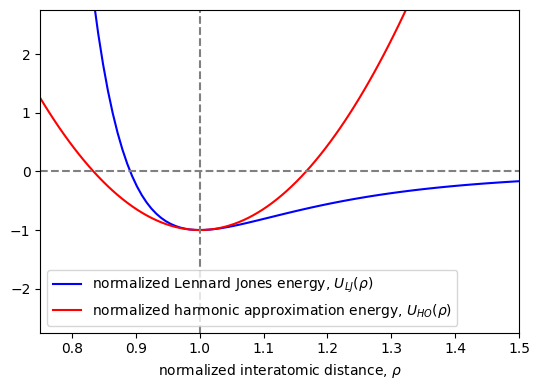

In [ ]:
rho = np.linspace(0.75,1.5,100)
lj_energy = normalized_lj_potential(rho)
harmonic_energy = 36*(rho - 1)**2 - 1

fig, ax = plt.subplots(figsize=(5.5,4))
ax.plot(rho,lj_energy,color='blue',label=r'normalized Lennard Jones energy, $U_{LJ}(\rho)$')
ax.plot(rho,harmonic_energy,color='red',label=r'normalized harmonic approximation energy, $U_{HO}(\rho)$')
ax.hlines([0],0.75,1.5,linestyles='dashed',color='gray')
ax.vlines(1.0,-2.75,2.75,linestyles='dashed',color='gray')
ax.set(
    xlim=[0.75,1.5],
    ylim=[-2.75,2.75],
    xlabel=r"normalized interatomic distance, $\rho$",
)
ax.legend()
fig.tight_layout()

For a harmonic oscillator, several properties simplify analytically:

- The motion is perfectly periodic, and the orbits in $(q,p)$ are ellipses.
- The period of the motion is independent of the energy.
  - As a result, the area enclosed by the orbit grows linearly with energy, so the multiplicity is constant and the entropy does not depend on energy.
- The heat capacity is constant and equal to $k_B$ at all temperatures.

Your task is to validate these results numerically by repeating the previous analysis, replacing the Lennard–Jones potential with the harmonic approximation:
- Compute phase-space orbits $(q(t), p(t))$ and verify that they are elliptical and that the period is independent of energy.
- Compute the enclosed area for each orbit, and verify that it grows linearly with energy, and that the multiplicity is constant.
- Compute the entropy and confirm that it is constant.
- Compute the partition function, internal energy, and heat capacity, and verify that $C \approx k_B$ for all temperatures.